# Task 1: Data Loading & Exploratory Data Analysis (EDA)
**Dataset:** DAIGT V2 Train Dataset (`train_v2_drcat_02.csv`)

**Mục tiêu:**
- Load và kiểm tra dữ liệu thô
- Phân tích missing values, duplicates
- EDA: phân phối nhãn, thống kê văn bản (số từ, ký tự, câu)
- Vẽ các biểu đồ trực quan hóa chuyên nghiệp

## 0. Import Libraries & Cấu hình

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import FancyBboxPatch

from collections import Counter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.style.use('seaborn-v0_8-darkgrid')
PALETTE = {'Human': '#4C9BE8', 'AI': '#E85D75'}
COLORS  = ['#4C9BE8', '#E85D75']
sns.set_palette(COLORS)
matplotlib.rcParams.update({
    'font.family':  'DejaVu Sans',
    'font.size':    12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi':   120,
})

ROOT      = Path('..').resolve()
DATA_DIR  = ROOT / 'data'
SAVE_DIR  = ROOT / 'outputs' / 'eda'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / 'train_v2_drcat_02.csv'

## 1. Data Loading & Tổng quan ban đầu

In [2]:
# Load dữ liệu 
print('[INFO] Đang tải dữ liệu...')
df = pd.read_csv(DATA_PATH)
print(f'Đã tải xong! Shape: {df.shape}')
print('\n' + '='*60)
print('THÔNG TIN CƠ BẢN')
print('='*60)
df.info()
print('\n' + '='*60)
print('5 DÒNG ĐẦU TIÊN')
print('='*60)
df.head()

[INFO] Đang tải dữ liệu...
Đã tải xong! Shape: (44868, 5)

THÔNG TIN CƠ BẢN
<class 'pandas.DataFrame'>
RangeIndex: 44868 entries, 0 to 44867
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   text           44868 non-null  str  
 1   label          44868 non-null  int64
 2   prompt_name    44868 non-null  str  
 3   source         44868 non-null  str  
 4   RDizzl3_seven  44868 non-null  bool 
dtypes: bool(1), int64(1), str(3)
memory usage: 98.0 MB

5 DÒNG ĐẦU TIÊN


,text,label,prompt_name,source,RDizzl3_seven
0,Phones\n\nModern humans today are always on their phone. They are always on their phone more than 5 hours a day no s...,0,Phones and driving,persuade_corpus,False
1,This essay will explain if drivers should or should not be able to use electronic devices while operating a vehicle....,0,Phones and driving,persuade_corpus,False
2,"Driving while the use of cellular devices\n\nToday, most of the society is thoughtless. Especially new drivers, all ...",0,Phones and driving,persuade_corpus,False
3,Phones & Driving\n\nDrivers should not be able to use phones while operating a vehicle. Drivers who used their phone...,0,Phones and driving,persuade_corpus,False
4,Cell Phone Operation While Driving\n\nThe ability to stay connected to people we know despite distance was originall...,0,Phones and driving,persuade_corpus,False


## 2. Kiểm tra Data Quality

In [ ]:
def check_data_quality(df: pd.DataFrame) -> pd.DataFrame:
    """
    Kiểm tra chất lượng dữ liệu toàn diện:
    - Missing values
    - Duplicate rows
    - Empty strings
    - Data types
    """
    print('='*70)
    print('BÁO CÁO CHẤT LƯỢNG DỮ LIỆU')
    print('='*70)

    # 2.1 Missing Values
    missing = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df) * 100).round(4)
    quality_df = pd.DataFrame({
        'Missing Count': missing,
        'Missing (%)': missing_pct,
        'Non-Null Count': df.notnull().sum(),
        'Dtype': df.dtypes
    })
    print('\nMissing Values:')
    print(quality_df.to_string())

    # 2.2 Duplicates
    n_dup = df.duplicated().sum()
    dup_text = df.duplicated(subset=['text']).sum() if 'text' in df.columns else 0
    print(f'\nDuplicate rows (toàn bộ): {n_dup:,} ({n_dup/len(df)*100:.2f}%)')
    print(f'Duplicate text:           {dup_text:,} ({dup_text/len(df)*100:.2f}%)')

    # 2.3 Empty strings
    if 'text' in df.columns:
        empty_str = (df['text'].str.strip() == '').sum()
        very_short = (df['text'].str.split().str.len() < 5).sum()
        print(f'Empty text strings:        {empty_str:,}')
        print(f'Text < 5 từ:               {very_short:,}')

    print('='*70)
    return quality_df

quality_report = check_data_quality(df)

🔍 BÁO CÁO CHẤT LƯỢNG DỮ LIỆU

Missing Values:
               Missing Count  Missing (%)  Non-Null Count  Dtype
text                       0       0.0000           44868    str
label                      0       0.0000           44868  int64
prompt_name                0       0.0000           44868    str
source                     0       0.0000           44868    str
RDizzl3_seven              0       0.0000           44868   bool

Duplicate rows (toàn bộ): 0 (0.00%)
Duplicate text:           0 (0.00%)
Empty text strings:        0
Text < 5 từ:               1


In [4]:
# Kiểm tra phân phối nhãn thô 
label_col = 'label'   
text_col  = 'text'

print('='*50)
print('PHÂN PHỐI NHÃN')
print('='*50)
label_counts = df[label_col].value_counts().sort_index()
label_pct    = df[label_col].value_counts(normalize=True).sort_index() * 100

label_summary = pd.DataFrame({
    'Nhãn':    {0: 'Human (0)', 1: 'AI (1)'},
    'Số lượng': label_counts,
    'Tỷ lệ (%)': label_pct.round(2)
})
print(label_summary.to_string())
print(f'\nTổng số mẫu: {len(df):,}')
print(f'Tỷ lệ mất cân bằng (Human/AI): {label_counts[0]/label_counts[1]:.2f}')

PHÂN PHỐI NHÃN
        Nhãn  Số lượng  Tỷ lệ (%)
0  Human (0)     27371    61.0000
1     AI (1)     17497    39.0000

Tổng số mẫu: 44,868
Tỷ lệ mất cân bằng (Human/AI): 1.56


## 3. Feature Engineering cho EDA
Tính toán các đặc trưng thống kê của văn bản để hỗ trợ phân tích.

In [5]:
def compute_text_features(df: pd.DataFrame, text_col: str = 'text') -> pd.DataFrame:
    """
    Tính toán các đặc trưng thống kê của văn bản:
    - word_count    : số từ
    - char_count    : số ký tự
    - sent_count    : số câu
    - avg_word_len  : độ dài trung bình mỗi từ
    - unique_words  : số từ duy nhất
    - lexical_diversity: unique_words / word_count
    - punct_count   : số dấu câu
    - digit_count   : số ký tự số
    - upper_ratio   : tỷ lệ chữ HOA
    """
    df = df.copy()
    texts = df[text_col].fillna('')

    # Số từ và ký tự
    words = texts.str.split()
    df['word_count']       = words.str.len()
    df['char_count']       = texts.str.len()

    # Số câu (chia theo '.', '!', '?')
    df['sent_count']       = texts.apply(lambda x: max(1, len(re.split(r'[.!?]+', x))))

    # Độ dài trung bình mỗi từ
    df['avg_word_len']     = words.apply(
        lambda ws: np.mean([len(w) for w in ws]) if ws and len(ws) > 0 else 0
    )

    # Số từ duy nhất & Lexical Diversity (Type-Token Ratio)
    df['unique_words']     = words.apply(lambda ws: len(set(ws)) if ws else 0)
    df['lexical_diversity']= df['unique_words'] / (df['word_count'] + 1e-6)

    # Dấu câu, chữ số, chữ HOA
    df['punct_count']      = texts.str.count(r'[^\w\s]')
    df['digit_count']      = texts.str.count(r'\d')
    df['upper_ratio']      = texts.apply(
        lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)
    )

    # Số từ trung bình mỗi câu
    df['words_per_sent']   = df['word_count'] / df['sent_count']

    return df

df = compute_text_features(df, text_col=text_col)

# Thống kê mô tả các đặc trưng
feat_cols = ['word_count', 'char_count', 'sent_count', 'avg_word_len',
             'unique_words', 'lexical_diversity', 'punct_count',
             'digit_count', 'upper_ratio', 'words_per_sent']

print('\nTHỐNG KÊ MÔ TẢ CÁC ĐẶC TRƯNG VĂN BẢN')
df[feat_cols].describe().round(4)


THỐNG KÊ MÔ TẢ CÁC ĐẶC TRƯNG VĂN BẢN


,word_count,char_count,sent_count,avg_word_len,unique_words,lexical_diversity,punct_count,digit_count,upper_ratio,words_per_sent
count,44868.0000,44868.0000,44868.0000,44868.0000,44868.0000,44868.0000,44868.0000,44868.0000,44868.0000,44868.0000
mean,383.6213,2216.2229,21.0450,4.7507,187.9688,0.5121,48.3580,3.4993,0.0157,19.2742
std,164.9261,969.9281,8.9968,0.7470,64.8034,0.0889,43.4878,7.2392,0.0158,9.5565
min,4.0000,48.0000,1.0000,3.1679,4.0000,0.0568,0.0000,0.0000,0.0000,1.0000
25%,274.0000,1564.7500,15.0000,4.4078,144.0000,0.4507,29.0000,0.0000,0.0096,15.6500
50%,352.0000,2044.0000,20.0000,4.6866,176.0000,0.5079,42.0000,0.0000,0.0135,18.2222
75%,451.0000,2619.0000,26.0000,5.0238,218.0000,0.5714,60.0000,4.0000,0.0196,21.1250
max,1656.0000,18322.0000,136.0000,126.2500,717.0000,1.0000,4507.0000,192.0000,0.8054,544.0000


In [6]:
# ── Thống kê theo nhãn ────────────────────────────────────────────────────────
print('\nTHỐNG KÊ THEO NHÃN (Human vs AI)')
print('='*70)

label_map = {0: 'Human', 1: 'AI'}
for col in ['word_count', 'char_count', 'sent_count', 'avg_word_len',
            'lexical_diversity', 'words_per_sent']:
    stats = df.groupby(label_col)[col].agg(['mean', 'median', 'std'])
    stats.index = stats.index.map(label_map)
    print(f'\n  {col}:')
    print(stats.round(4).to_string())


THỐNG KÊ THEO NHÃN (Human vs AI)

  word_count:
          mean   median      std
label                           
Human 418.2831 383.0000 189.2859
AI    329.3990 328.0000  94.2565

  char_count:
           mean    median       std
label                              
Human 2348.5039 2132.0000 1124.4899
AI    2009.2925 1973.0000  603.4964

  sent_count:
         mean  median     std
label                        
Human 22.3112 21.0000 10.1529
AI    19.0641 19.0000  6.3149

  avg_word_len:
        mean  median    std
label                      
Human 4.5315  4.5226 0.3298
AI    5.0936  5.0641 1.0335

  lexical_diversity:
        mean  median    std
label                      
Human 0.5008  0.5013 0.0844
AI    0.5297  0.5190 0.0929

  words_per_sent:
         mean  median     std
label                        
Human 20.1744 18.5333 11.8358
AI    17.8660 17.8947  3.4356


## 4. Visualizations — Biểu đồ EDA

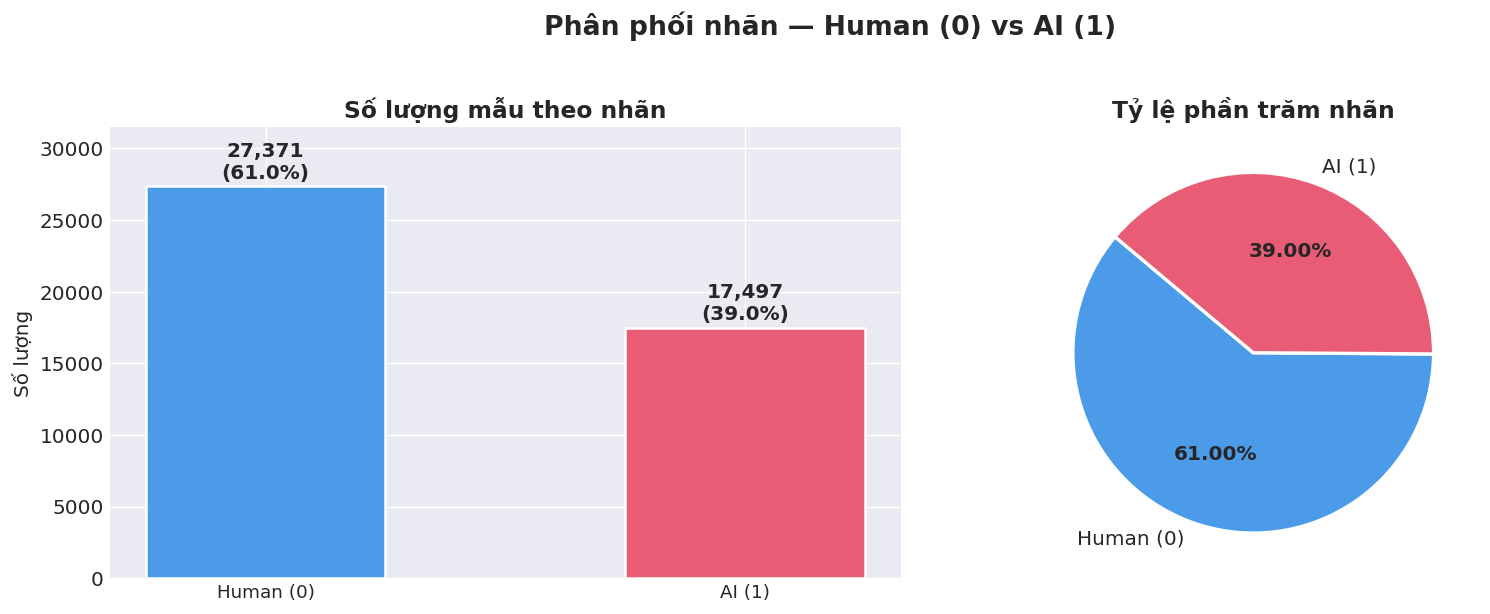

[INFO] Đã lưu: D:\GitHub\Detect-AI-Generated-Text-Using-LLM\outputs\eda\fig1_label_distribution.png


In [7]:
#  Fig 1: Label Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phân phối nhãn — Human (0) vs AI (1)', fontsize=16, fontweight='bold', y=1.02)

label_names = ['Human (0)', 'AI (1)']
counts  = [label_counts.get(0, 0), label_counts.get(1, 0)]
pcts    = [counts[0]/sum(counts)*100, counts[1]/sum(counts)*100]

# --- Bar chart ---
bars = axes[0].bar(label_names, counts, color=COLORS, edgecolor='white',
                   linewidth=1.5, width=0.5)
axes[0].set_title('Số lượng mẫu theo nhãn', fontweight='bold')
axes[0].set_ylabel('Số lượng')
for bar, cnt, pct in zip(bars, counts, pcts):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(counts)*0.01,
                 f'{cnt:,}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(counts) * 1.15)
axes[0].tick_params(axis='x', labelsize=11)
sns.despine(ax=axes[0], left=False, bottom=False)

# --- Pie chart ---
wedges, texts, autotexts = axes[1].pie(
    counts, labels=label_names, colors=COLORS,
    autopct='%1.2f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[1].set_title('Tỷ lệ phần trăm nhãn', fontweight='bold')

plt.tight_layout()
plt.savefig(SAVE_DIR / 'fig1_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[INFO] Đã lưu: {SAVE_DIR / "fig1_label_distribution.png"}')

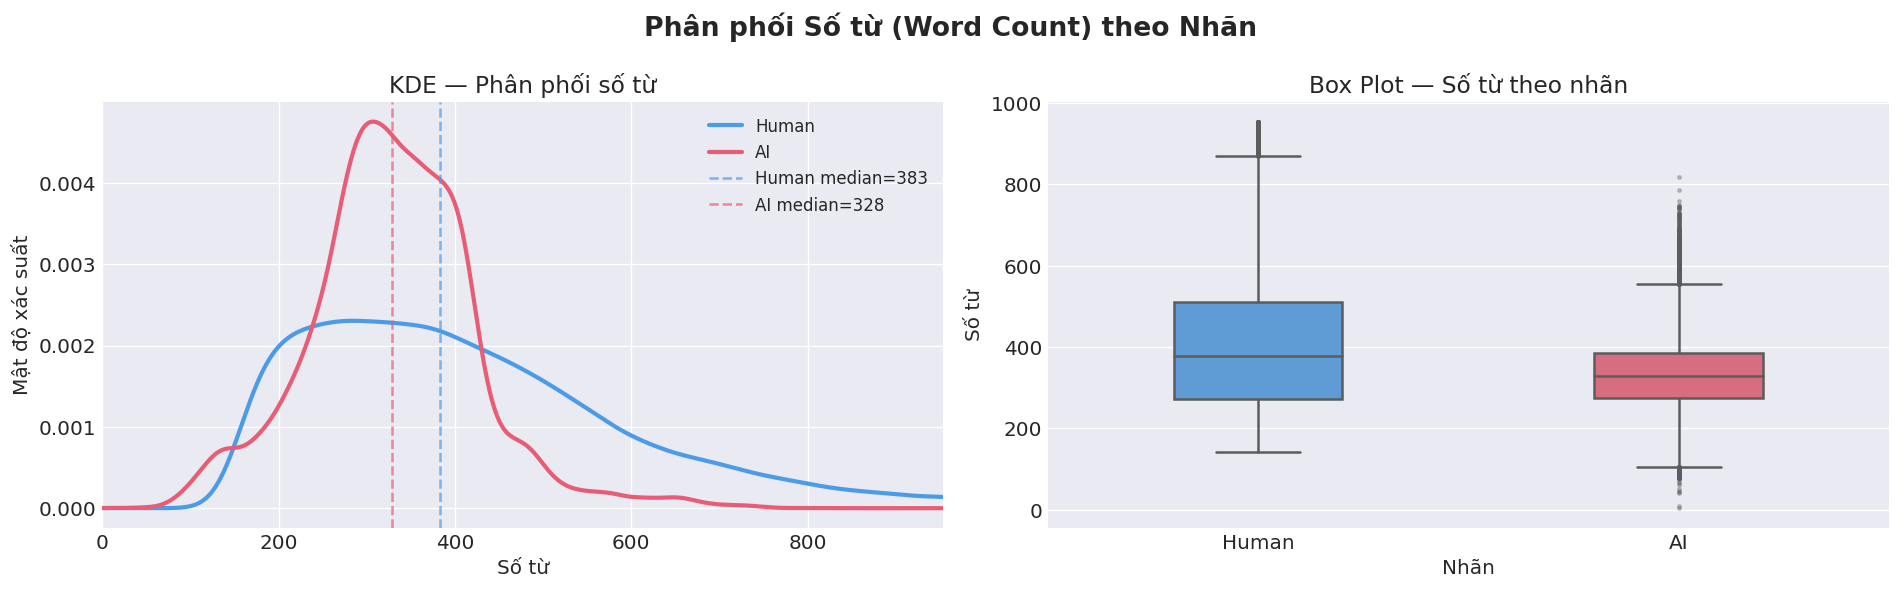

[INFO] Đã lưu: D:\GitHub\Detect-AI-Generated-Text-Using-LLM\outputs\eda\fig2_word_count_distribution.png


In [8]:
#  Fig 2: Word Count Distribution

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Phân phối Số từ (Word Count) theo Nhãn', fontsize=16, fontweight='bold')

human_wc = df[df[label_col] == 0]['word_count']
ai_wc    = df[df[label_col] == 1]['word_count']

# --- KDE plot ---
human_wc.plot.kde(ax=axes[0], color=COLORS[0], linewidth=2.5, label='Human')
ai_wc.plot.kde(ax=axes[0],    color=COLORS[1], linewidth=2.5, label='AI')
axes[0].axvline(human_wc.median(), color=COLORS[0], linestyle='--', alpha=0.7,
                label=f'Human median={human_wc.median():.0f}')
axes[0].axvline(ai_wc.median(),    color=COLORS[1], linestyle='--', alpha=0.7,
                label=f'AI median={ai_wc.median():.0f}')
axes[0].set_xlabel('Số từ')
axes[0].set_ylabel('Mật độ xác suất')
axes[0].set_title('KDE — Phân phối số từ')
axes[0].legend(fontsize=10)
axes[0].set_xlim(0, df['word_count'].quantile(0.99))  # loại bỏ outlier cực đoan
sns.despine(ax=axes[0])

# --- Box plot ---
df_plot = df[[label_col, 'word_count']].copy()
df_plot['Nhãn'] = df_plot[label_col].map({0: 'Human', 1: 'AI'})
df_plot_filt = df_plot[df_plot['word_count'] <= df_plot['word_count'].quantile(0.99)]

sns.boxplot(data=df_plot_filt, x='Nhãn', y='word_count',
            palette=PALETTE, ax=axes[1],
            width=0.4, flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3})
axes[1].set_title('Box Plot — Số từ theo nhãn')
axes[1].set_xlabel('Nhãn')
axes[1].set_ylabel('Số từ')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(SAVE_DIR / 'fig2_word_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[INFO] Đã lưu: {SAVE_DIR / "fig2_word_count_distribution.png"}')

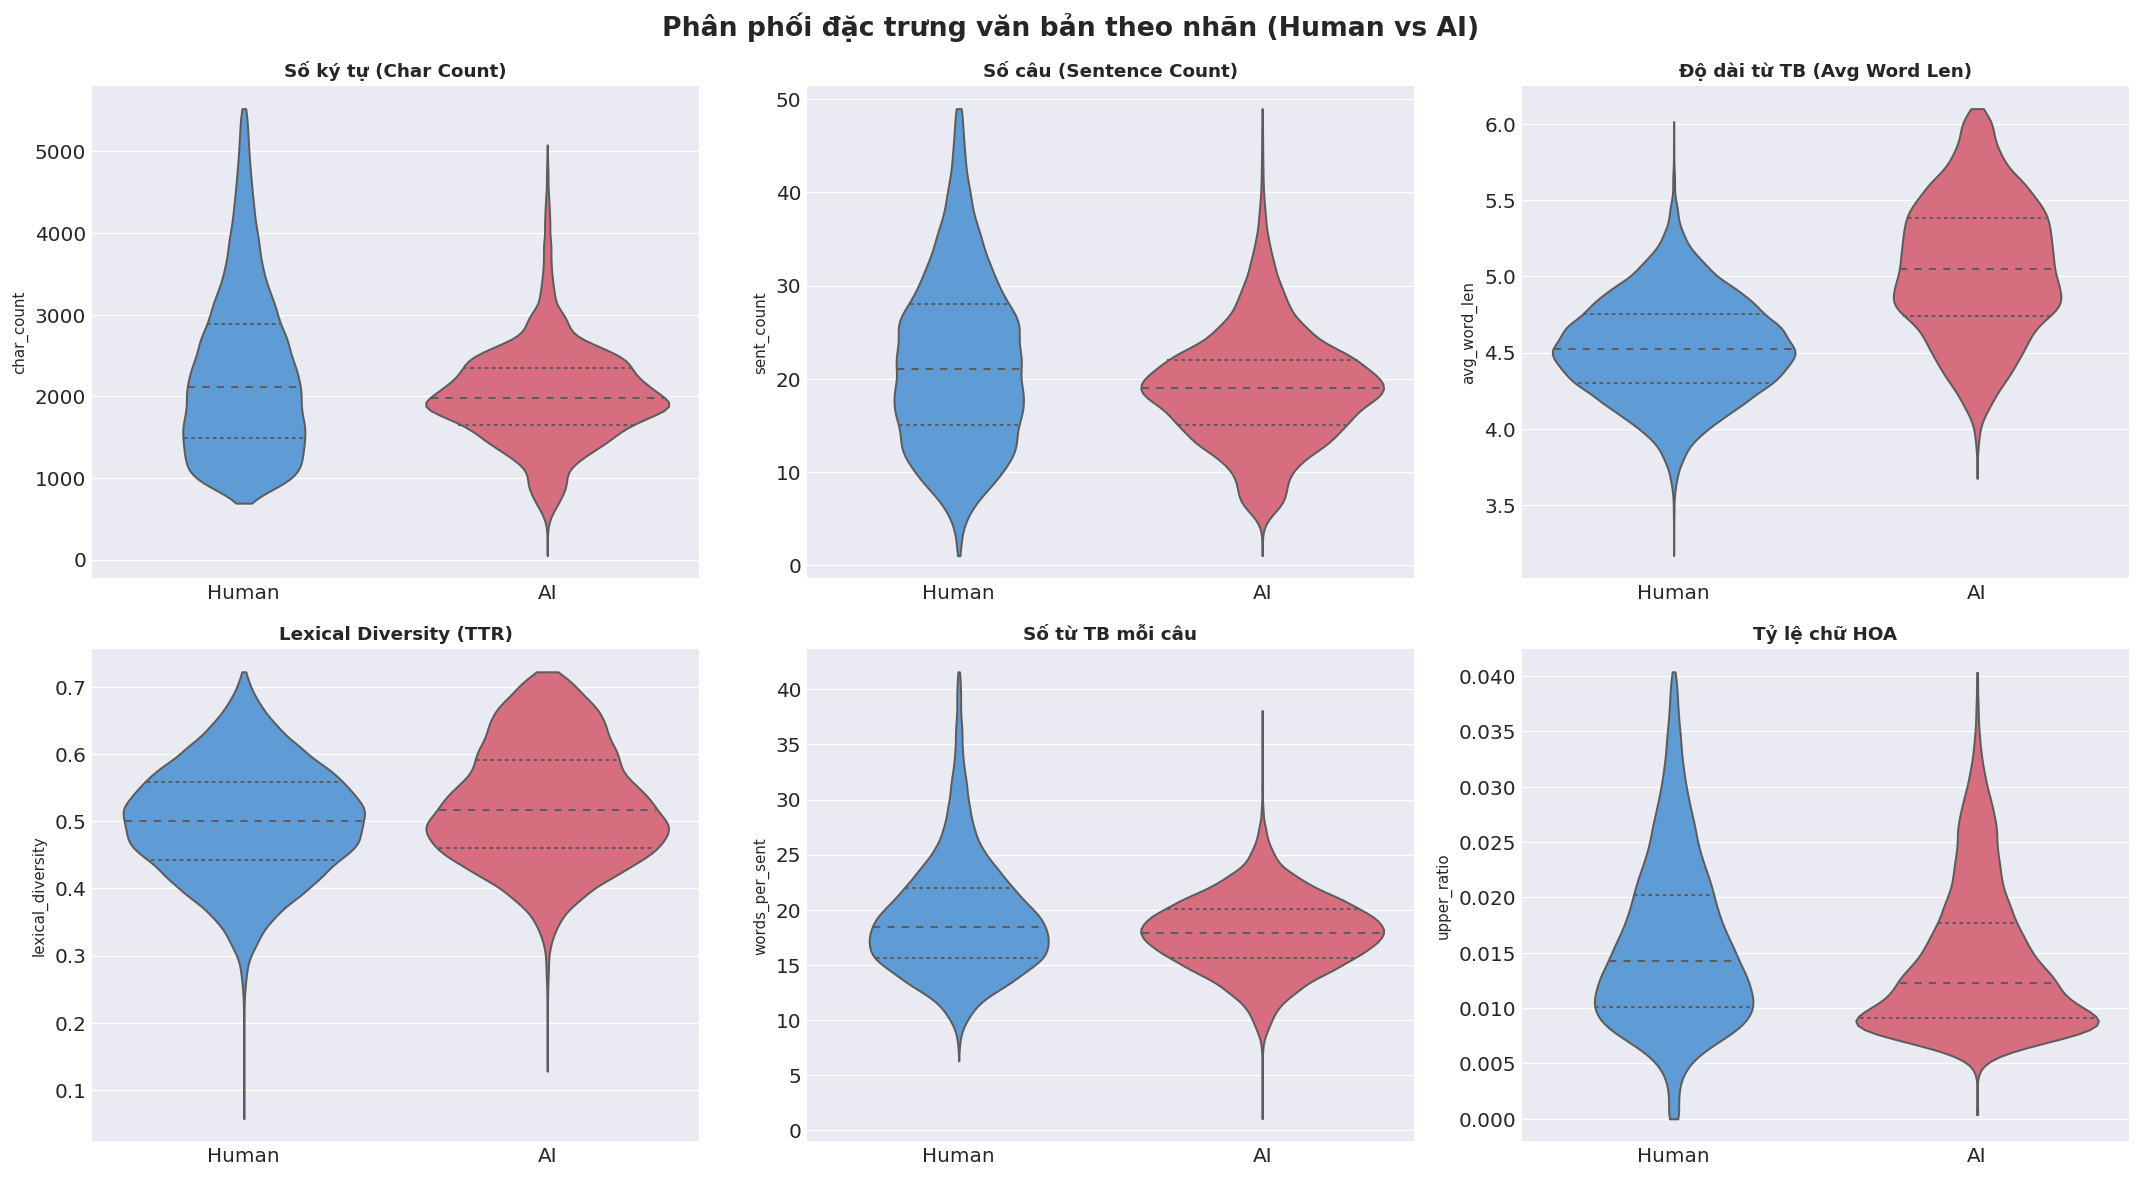

[INFO] Đã lưu: D:\GitHub\Detect-AI-Generated-Text-Using-LLM\outputs\eda\fig3_feature_distribution.png


In [9]:
#  Fig 3: Multi-feature Distribution (violin + box)
features_to_plot = [
    ('char_count',       'Số ký tự (Char Count)'),
    ('sent_count',       'Số câu (Sentence Count)'),
    ('avg_word_len',     'Độ dài từ TB (Avg Word Len)'),
    ('lexical_diversity','Lexical Diversity (TTR)'),
    ('words_per_sent',   'Số từ TB mỗi câu'),
    ('upper_ratio',      'Tỷ lệ chữ HOA'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Phân phối đặc trưng văn bản theo nhãn (Human vs AI)',
             fontsize=16, fontweight='bold')

df_vis = df[[label_col] + [f for f, _ in features_to_plot]].copy()
df_vis['Nhãn'] = df_vis[label_col].map({0: 'Human', 1: 'AI'})

for ax, (feat, title) in zip(axes.flatten(), features_to_plot):
    # Loại bỏ outlier tại 99th percentile để violin rõ hơn
    p99 = df_vis[feat].quantile(0.99)
    df_filt = df_vis[df_vis[feat] <= p99]

    sns.violinplot(data=df_filt, x='Nhãn', y=feat,
                   palette=PALETTE, ax=ax, inner='quartile',
                   cut=0, linewidth=1.2)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel(feat, fontsize=9)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'fig3_feature_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[INFO] Đã lưu: {SAVE_DIR / "fig3_feature_distribution.png"}')

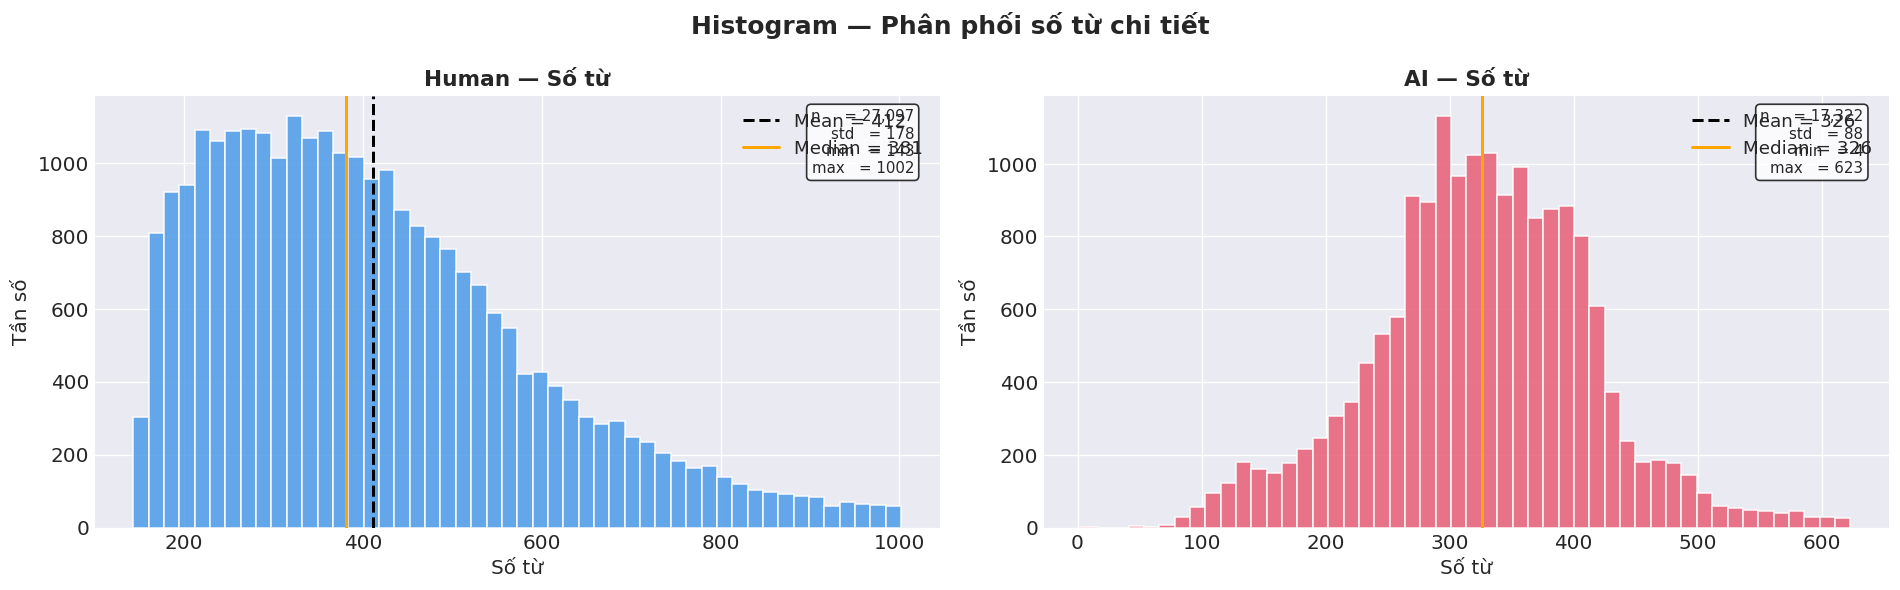

In [10]:
#  Fig 4: Histogram — Word Count bins (chi tiết)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Histogram — Phân phối số từ chi tiết', fontsize=15, fontweight='bold')

for i, (label_id, label_name) in enumerate([(0, 'Human'), (1, 'AI')]):
    data = df[df[label_col] == label_id]['word_count']
    data = data[data <= data.quantile(0.99)]
    axes[i].hist(data, bins=50, color=COLORS[i], alpha=0.85, edgecolor='white')
    axes[i].axvline(data.mean(),   color='black',  linestyle='--', lw=1.8,
                    label=f'Mean = {data.mean():.0f}')
    axes[i].axvline(data.median(), color='orange', linestyle='-',  lw=1.8,
                    label=f'Median = {data.median():.0f}')
    axes[i].set_title(f'{label_name} — Số từ', fontweight='bold', fontsize=13)
    axes[i].set_xlabel('Số từ')
    axes[i].set_ylabel('Tần số')
    axes[i].legend(fontsize=11)
    # Thêm thống kê text box
    textstr = (f'n     = {len(data):,}\n'
               f'std   = {data.std():.0f}\n'
               f'min   = {data.min():.0f}\n'
               f'max   = {data.max():.0f}')
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    axes[i].text(0.97, 0.97, textstr, transform=axes[i].transAxes,
                 fontsize=9, verticalalignment='top', horizontalalignment='right',
                 bbox=props)
    sns.despine(ax=axes[i])

plt.tight_layout()
plt.savefig(SAVE_DIR / 'fig4_word_count_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

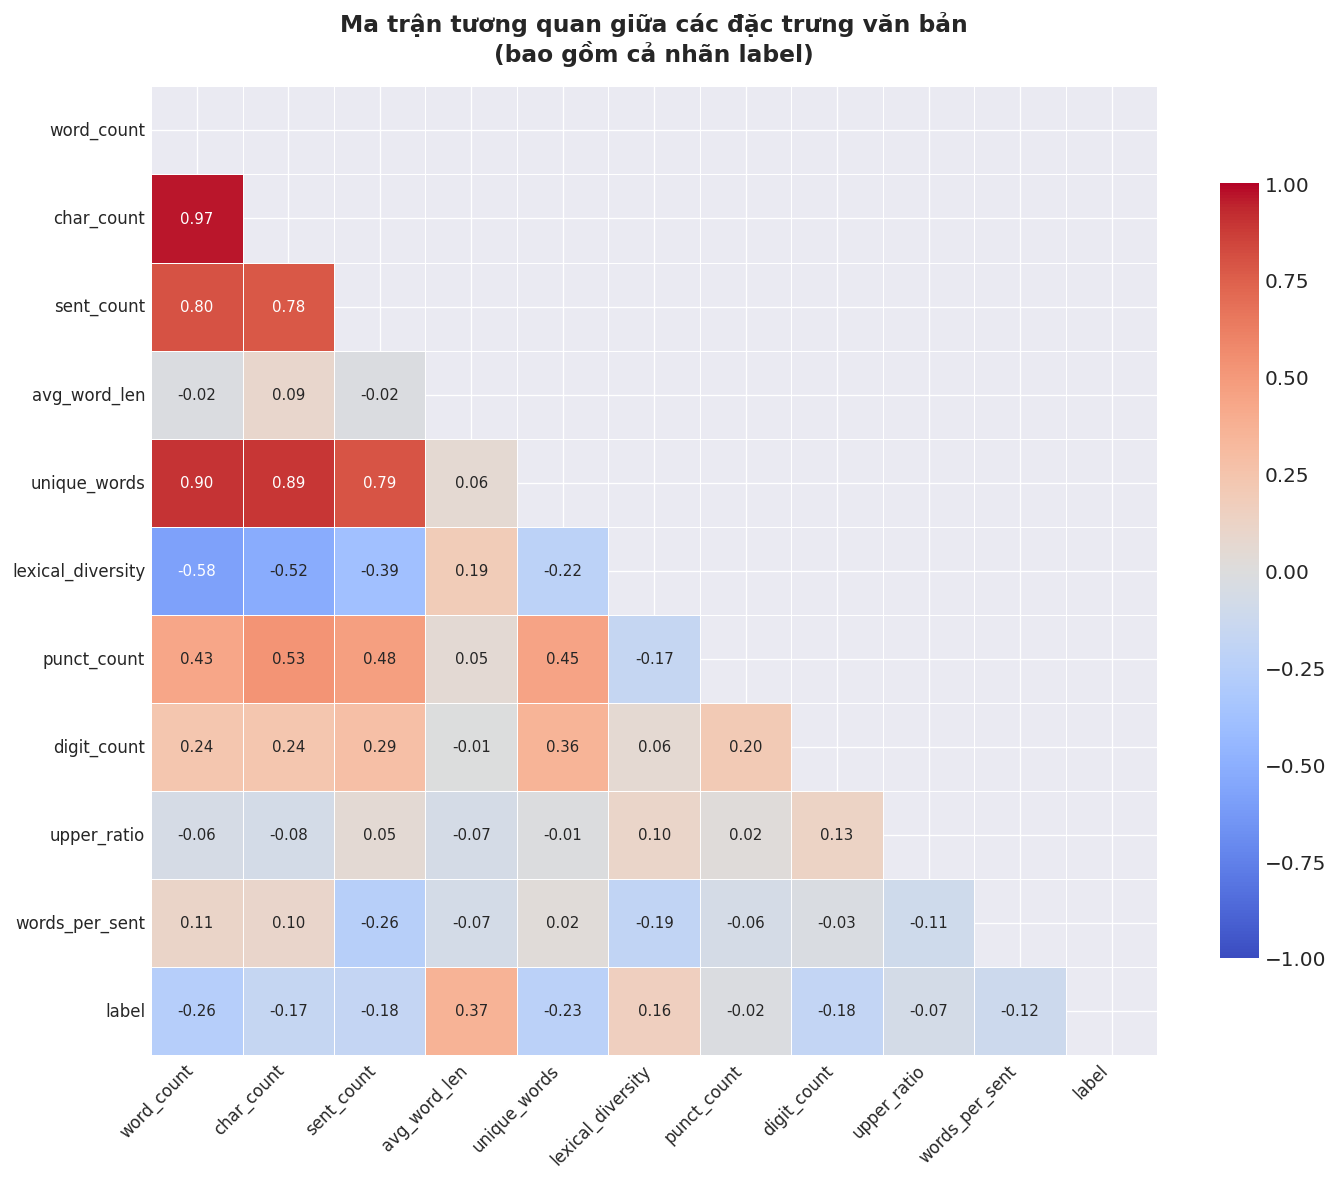

[INFO] Đã lưu: D:\GitHub\Detect-AI-Generated-Text-Using-LLM\outputs\eda\fig5_correlation_heatmap.png


In [11]:
#  Fig 5: Correlation Heatmap — Text Features
corr_feats = ['word_count', 'char_count', 'sent_count', 'avg_word_len',
              'unique_words', 'lexical_diversity', 'punct_count',
              'digit_count', 'upper_ratio', 'words_per_sent', label_col]

corr_matrix = df[corr_feats].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # chỉ hiện tam giác dưới
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 9},
            cbar_kws={'shrink': 0.8})
ax.set_title('Ma trận tương quan giữa các đặc trưng văn bản\n(bao gồm cả nhãn label)',
             fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'fig5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[INFO] Đã lưu: {SAVE_DIR / "fig5_correlation_heatmap.png"}')

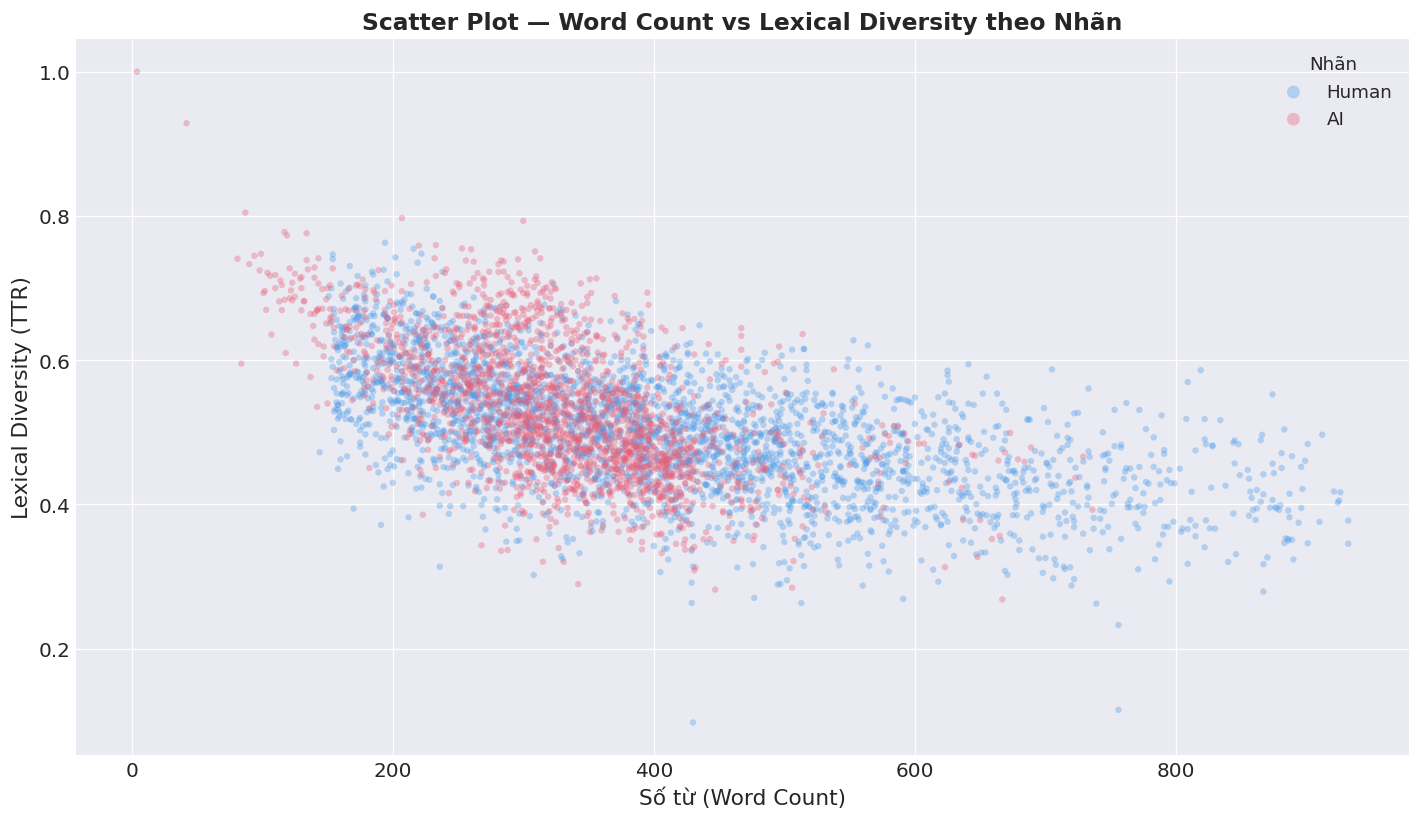

In [12]:
#  Fig 6: Scatter — Word Count vs Lexical Diversity (by label)
sample_df = df.sample(min(5000, len(df)), random_state=42)  # sample để vẽ nhanh
sample_df['Nhãn'] = sample_df[label_col].map({0: 'Human', 1: 'AI'})
sample_df = sample_df[sample_df['word_count'] <= sample_df['word_count'].quantile(0.99)]

fig, ax = plt.subplots(figsize=(12, 7))
for label_name, color in PALETTE.items():
    subset = sample_df[sample_df['Nhãn'] == label_name]
    ax.scatter(subset['word_count'], subset['lexical_diversity'],
               c=color, label=label_name, alpha=0.35, s=15, edgecolors='none')

ax.set_xlabel('Số từ (Word Count)', fontsize=13)
ax.set_ylabel('Lexical Diversity (TTR)', fontsize=13)
ax.set_title('Scatter Plot — Word Count vs Lexical Diversity theo Nhãn',
             fontsize=14, fontweight='bold')
ax.legend(title='Nhãn', fontsize=11, title_fontsize=11,
          markerscale=2, framealpha=0.9)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'fig6_scatter_wc_vs_ld.png', dpi=150, bbox_inches='tight')
plt.show()

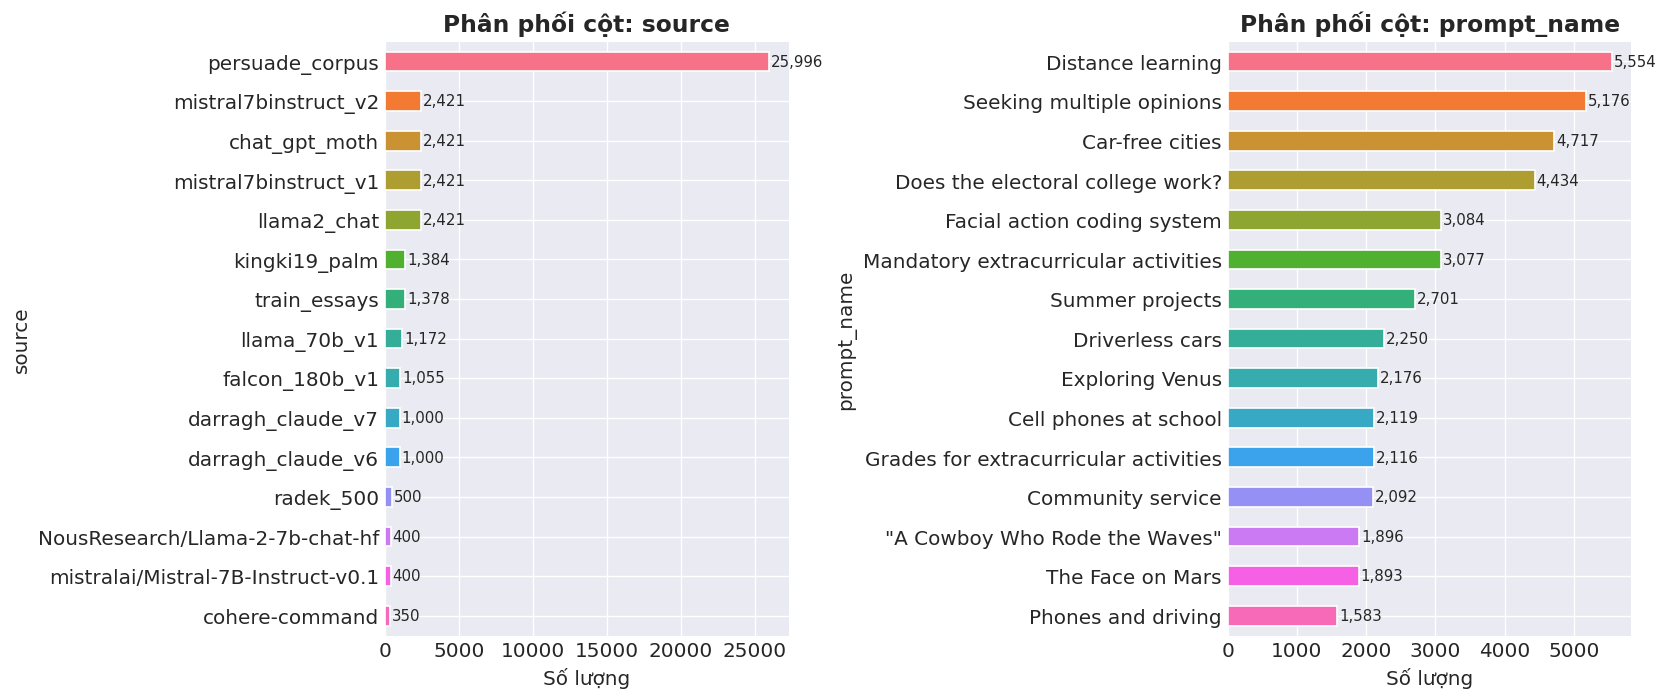

In [13]:
#  Fig 7: Source/Model Distribution (nếu dataset có cột này)
meta_cols = [c for c in ['source', 'model', 'prompt_name'] if c in df.columns]

if meta_cols:
    fig, axes = plt.subplots(1, len(meta_cols),
                             figsize=(7 * len(meta_cols), 6))
    if len(meta_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, meta_cols):
        counts = df[col].value_counts().head(15)
        colors_bar = sns.color_palette('husl', len(counts))
        counts.plot.barh(ax=ax, color=colors_bar, edgecolor='white')
        ax.set_title(f'Phân phối cột: {col}', fontweight='bold')
        ax.set_xlabel('Số lượng')
        ax.invert_yaxis()
        for i, (idx, val) in enumerate(counts.items()):
            ax.text(val + max(counts)*0.005, i, f'{val:,}', va='center', fontsize=9)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.savefig(SAVE_DIR / 'fig7_meta_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('[INFO] Không tìm thấy cột metadata (source/model/prompt_name).')

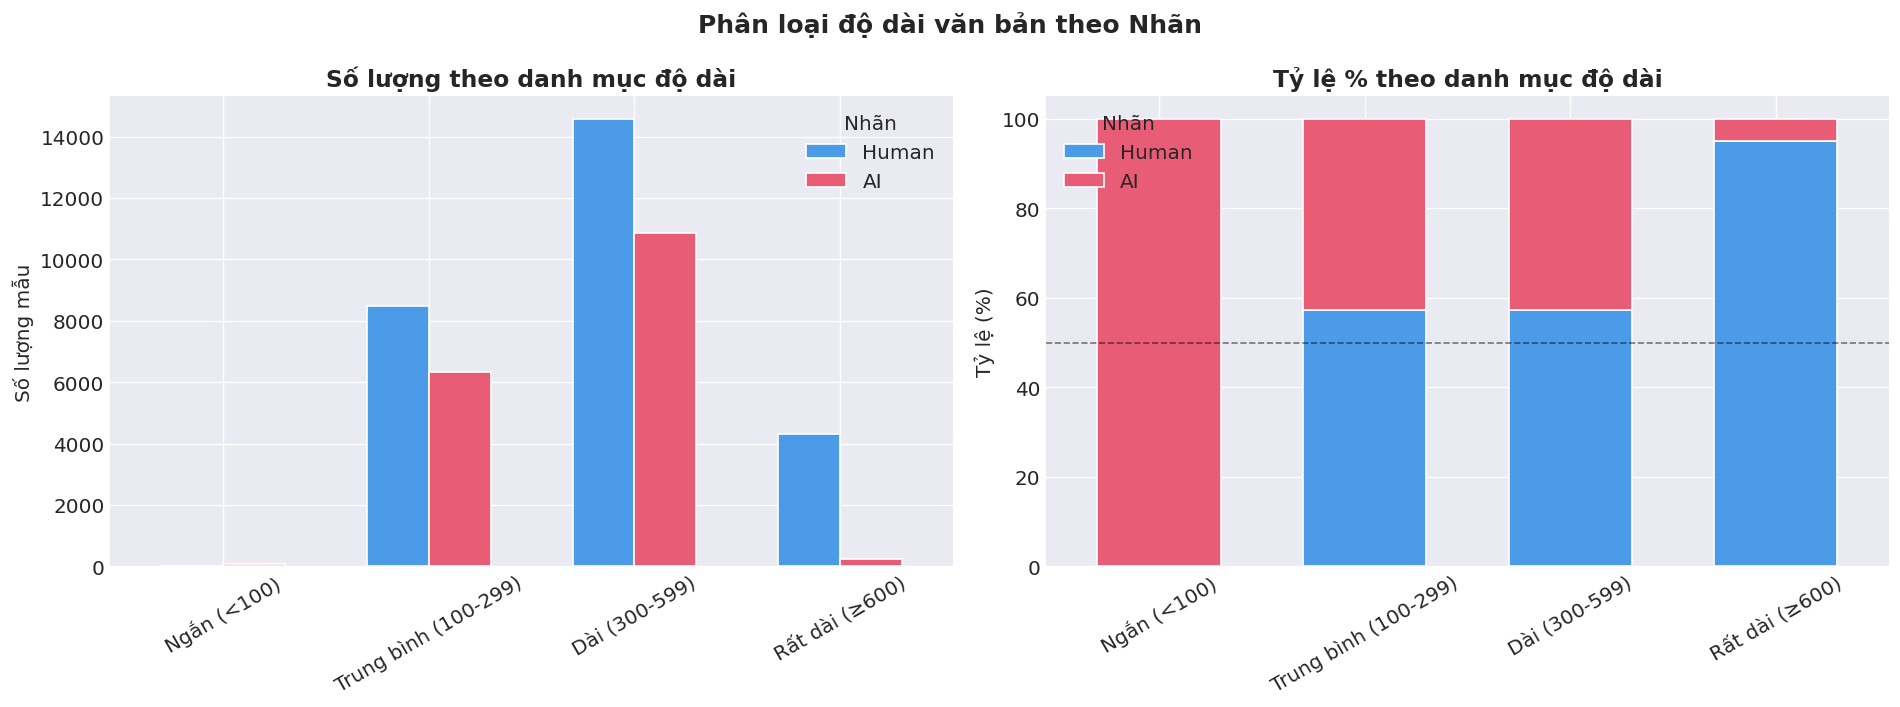

In [14]:
#  Fig 8: Text Length Category — Short / Medium / Long / Very Long
def categorize_length(wc):
    if wc < 100:   return 'Ngắn (<100)'
    elif wc < 300: return 'Trung bình (100-299)'
    elif wc < 600: return 'Dài (300-599)'
    else:          return 'Rất dài (≥600)'

df['length_cat'] = df['word_count'].apply(categorize_length)
cat_order = ['Ngắn (<100)', 'Trung bình (100-299)', 'Dài (300-599)', 'Rất dài (≥600)']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phân loại độ dài văn bản theo Nhãn', fontsize=15, fontweight='bold')

# Stacked bar
pivot = df.groupby(['length_cat', label_col]).size().unstack(fill_value=0)
pivot.index = pd.CategoricalIndex(pivot.index, categories=cat_order, ordered=True)
pivot = pivot.sort_index()
pivot.columns = ['Human', 'AI']
pivot.plot(kind='bar', ax=axes[0], color=COLORS, edgecolor='white',
           stacked=False, width=0.6)
axes[0].set_title('Số lượng theo danh mục độ dài', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Số lượng mẫu')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Nhãn')
sns.despine(ax=axes[0])

# 100% stacked bar
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct.plot(kind='bar', ax=axes[1], color=COLORS, edgecolor='white',
               stacked=True, width=0.6)
axes[1].set_title('Tỷ lệ % theo danh mục độ dài', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Tỷ lệ (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Nhãn')
axes[1].axhline(50, color='black', linestyle='--', alpha=0.5, lw=1)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(SAVE_DIR / 'fig8_length_category.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Phân tích mẫu văn bản

In [15]:
# Xem ví dụ mẫu văn bản từ mỗi nhãn 
np.random.seed(42)

print('='*70)
print('VÍ DỤ VĂN BẢN — HUMAN (label=0)')
print('='*70)
human_sample = df[df[label_col] == 0][text_col].sample(2).values
for i, text in enumerate(human_sample, 1):
    print(f'\n[Mẫu {i}]')
    print(text[:600] + '...' if len(text) > 600 else text)
    print()

print('='*70)
print('VÍ DỤ VĂN BẢN — AI (label=1)')
print('='*70)
ai_sample = df[df[label_col] == 1][text_col].sample(2).values
for i, text in enumerate(ai_sample, 1):
    print(f'\n[Mẫu {i}]')
    print(text[:600] + '...' if len(text) > 600 else text)
    print()

VÍ DỤ VĂN BẢN — HUMAN (label=0)

[Mẫu 1]
Are you looking for something to do in your life? If your are then you should join the Seagoing Cowboy program. At first you will have a meloncoly demeanor,but you will get use to traveling and being away from home. The animals you take care of will give you an exubernt feeling. Also, you will be able to vist many different places around the world. You will have alot of fun with to people you meet on the ship. We have alot of things you can do when you get off the ship like you can have fun by doing sports.

You will have to take care of animals from all over the world. You will have to feed t...


[Mẫu 2]
Dear principal,

It has come to attention that you are considering changing school policy so that students may not participate in sport of other activities unless they have at least a grade B average. Of course, many students have a C average. It is my opinion that students should be allowed to play sports even thought they have a C average. I

## 6. Tổng kết EDA & Insight

In [16]:
# Tổng kết số liệu 
print()
print('━'*70)
print('TỔNG KẾT EDA — Task 1')
print('━'*70)

human_df = df[df[label_col] == 0]
ai_df    = df[df[label_col] == 1]

rows = [
    ('Tổng số mẫu', f"{len(df):,}"),
    ('  - Human (0)', f"{len(human_df):,} ({len(human_df)/len(df)*100:.1f}%)"),
    ('  - AI (1)',    f"{len(ai_df):,} ({len(ai_df)/len(df)*100:.1f}%)"),
    ('Missing values (text)', f"{df[text_col].isnull().sum():,}"),
    ('Duplicate rows', f"{df.duplicated().sum():,}"),
    ('Duplicate text', f"{df.duplicated(subset=[text_col]).sum():,}"),
    ('', ''),
    ('[Human] Số từ TB',   f"{human_df['word_count'].mean():.0f} ± {human_df['word_count'].std():.0f}"),
    ('[AI]    Số từ TB',   f"{ai_df['word_count'].mean():.0f} ± {ai_df['word_count'].std():.0f}"),
    ('[Human] Lexical Diversity TB', f"{human_df['lexical_diversity'].mean():.4f}"),
    ('[AI]    Lexical Diversity TB', f"{ai_df['lexical_diversity'].mean():.4f}"),
    ('[Human] Số câu TB', f"{human_df['sent_count'].mean():.1f}"),
    ('[AI]    Số câu TB', f"{ai_df['sent_count'].mean():.1f}"),
]

for key, val in rows:
    if key == '':
        print()
    else:
        print(f'  {key:<40} {val}')




━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TỔNG KẾT EDA — Task 1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Tổng số mẫu                              44,868
    - Human (0)                            27,371 (61.0%)
    - AI (1)                               17,497 (39.0%)
  Missing values (text)                    0
  Duplicate rows                           0
  Duplicate text                           0

  [Human] Số từ TB                         418 ± 189
  [AI]    Số từ TB                         329 ± 94
  [Human] Lexical Diversity TB             0.5008
  [AI]    Lexical Diversity TB             0.5297
  [Human] Số câu TB                        22.3
  [AI]    Số câu TB                        19.1


Nhận xét:
* Kiểm tra tỷ lệ mất cân bằng nhãn — ảnh hưởng đến chiến lược huấn luyện
* Văn bản AI thường có lexical diversity thấp hơn (lặp từ nhiều hơn)
* Phân phối số từ có thể khác biệt đáng kể giữa Human và AI
* Duplicate text cần được xử lý trước khi split train/valid
* Văn bản rất ngắn (<50 từ) cần được xem xét loại bỏ hoặc xử lý riêng

In [17]:
# Lưu DataFrame 
feat_path = DATA_DIR / 'train_with_features.pkl'
df.to_pickle(feat_path)
print(f'Đã lưu DataFrame có features tại: {feat_path}')
print(f'Shape: {df.shape}')
print(f' Columns: {df.columns.tolist()}')

Đã lưu DataFrame có features tại: D:\GitHub\Detect-AI-Generated-Text-Using-LLM\data\train_with_features.pkl
Shape: (44868, 16)
 Columns: ['text', 'label', 'prompt_name', 'source', 'RDizzl3_seven', 'word_count', 'char_count', 'sent_count', 'avg_word_len', 'unique_words', 'lexical_diversity', 'punct_count', 'digit_count', 'upper_ratio', 'words_per_sent', 'length_cat']
